In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("DATA/state_MN.csv", low_memory=False)
print(df.shape)
print(df.head())

(175162, 99)
   activity_year                   lei  derived_msa-md state_code  \
0           2023  549300VZVN841I2ILS84           33460         MN   
1           2023  549300VZVN841I2ILS84           33460         MN   
2           2023  549300VZVN841I2ILS84           33460         MN   
3           2023  549300VZVN841I2ILS84           33460         MN   
4           2023  549300VZVN841I2ILS84           99999         MN   

   county_code  census_tract conforming_loan_limit derived_loan_product_type  \
0      27053.0  2.705302e+10                     C            FHA:First Lien   
1      27003.0  2.700305e+10                     C   Conventional:First Lien   
2      27037.0  2.703706e+10                     C   Conventional:First Lien   
3      27003.0  2.700305e+10                     C   Conventional:First Lien   
4      27113.0  2.711309e+10                     C            FHA:First Lien   

              derived_dwelling_category        derived_ethnicity  ...  \
0  Single Family (

In [9]:
data = df[[
    "loan_amount",
    "property_value",
    "income",
    "derived_race",
    "action_taken",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage"
]]

print(data.describe())

        loan_amount        income   action_taken  \
count  1.751620e+05  1.585620e+05  175162.000000   
mean   2.473005e+05  1.452782e+02       2.254856   
std    8.116534e+05  4.222598e+03       1.756014   
min    5.000000e+03 -3.415700e+04       1.000000   
25%    8.500000e+04  6.700000e+01       1.000000   
50%    1.950000e+05  9.800000e+01       1.000000   
75%    3.150000e+05  1.500000e+02       3.000000   
max    1.000050e+08  1.651000e+06       8.000000   

       tract_minority_population_percent  tract_to_msa_income_percentage  
count                      175162.000000                   175162.000000  
mean                           21.964327                      103.109585  
std                            16.842531                       32.052789  
min                             0.000000                        0.000000  
25%                             9.790000                       83.810000  
50%                            17.630000                      100.280000  
75%   

##  Loan Approval Distribution

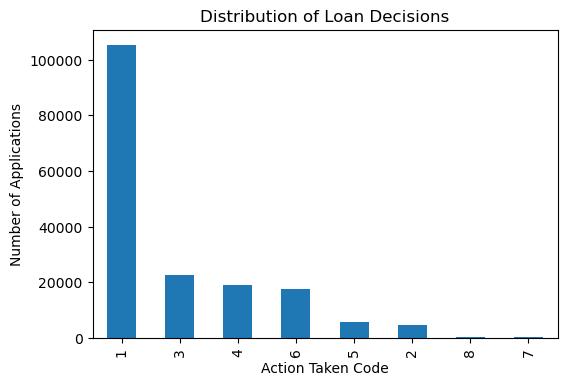

In [11]:
approval_counts = df["action_taken"].value_counts()

plt.figure(figsize=(6,4))
approval_counts.plot(kind="bar")

plt.title("Distribution of Loan Decisions")
plt.xlabel("Action Taken Code")
plt.ylabel("Number of Applications")

plt.show()

## Property Value Distribution

C:\Users\Tanvi\AppData\Local\Temp\ipykernel_23828\488307773.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["minority_group"] = pd.cut(


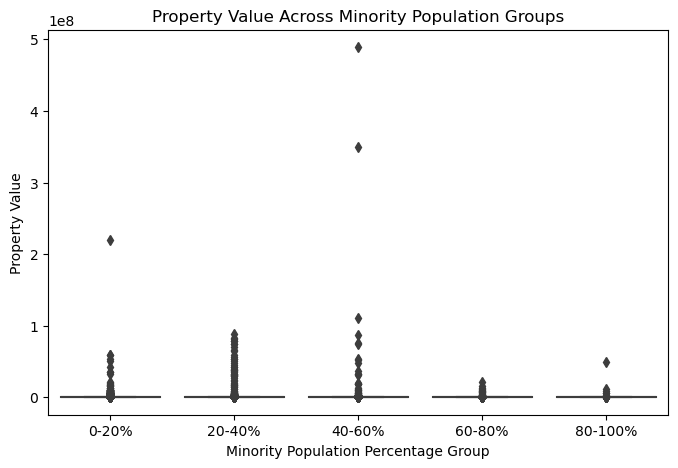

In [45]:
# convert columns to numeric
df["property_value"] = pd.to_numeric(df["property_value"], errors="coerce")
df["tract_minority_population_percent"] = pd.to_numeric(
    df["tract_minority_population_percent"], errors="coerce"
)

# remove missing values
df_clean = df.dropna(subset=["property_value","tract_minority_population_percent"])


# create minority population groups
df_clean["minority_group"] = pd.cut(
    df_clean["tract_minority_population_percent"],
    bins=[0,20,40,60,80,100],
    labels=["0-20%","20-40%","40-60%","60-80%","80-100%"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x="minority_group",
    y="property_value",
    data=df_clean
)

plt.title("Property Value Across Minority Population Groups")
plt.xlabel("Minority Population Percentage Group")
plt.ylabel("Property Value")

plt.show()

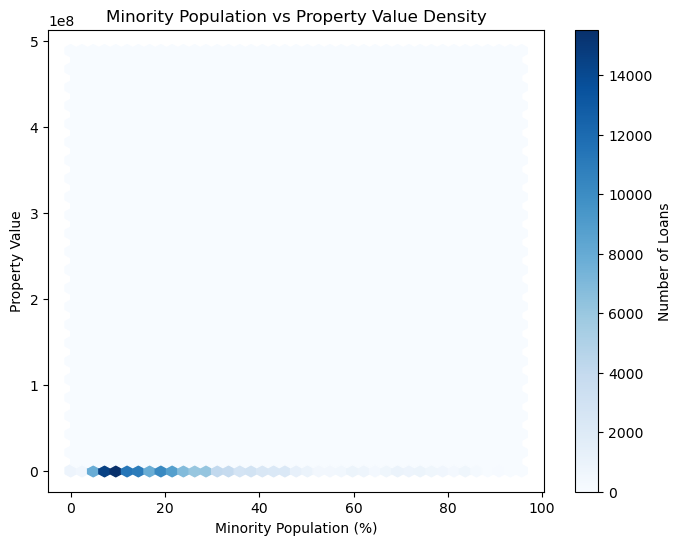

In [47]:
plt.figure(figsize=(8,6))

plt.hexbin(
    df["tract_minority_population_percent"],
    df["property_value"],
    gridsize=40,
    cmap="Blues"
)

plt.colorbar(label="Number of Loans")

plt.xlabel("Minority Population (%)")
plt.ylabel("Property Value")
plt.title("Minority Population vs Property Value Density")

plt.show()

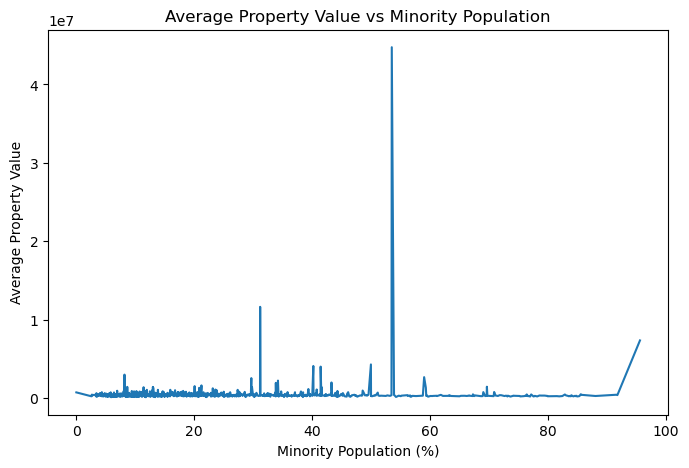

In [49]:
df_grouped = df.groupby("tract_minority_population_percent")["property_value"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    x="tract_minority_population_percent",
    y="property_value",
    data=df_grouped
)

plt.title("Average Property Value vs Minority Population")
plt.xlabel("Minority Population (%)")
plt.ylabel("Average Property Value")

plt.show()

## Minority Population vs Property Value

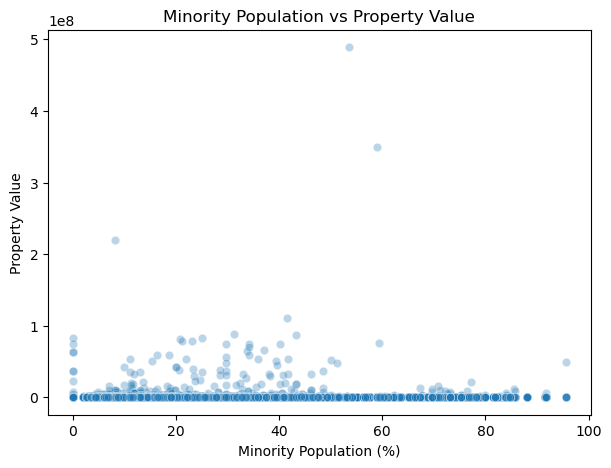

In [51]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="tract_minority_population_percent",
    y="property_value",
    data=df,
    alpha=0.3
)

plt.title("Minority Population vs Property Value")
plt.xlabel("Minority Population (%)")
plt.ylabel("Property Value")

plt.show()

C:\Users\Tanvi\AppData\Local\Temp\ipykernel_23828\4248832205.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["minority_group"] = pd.cut(


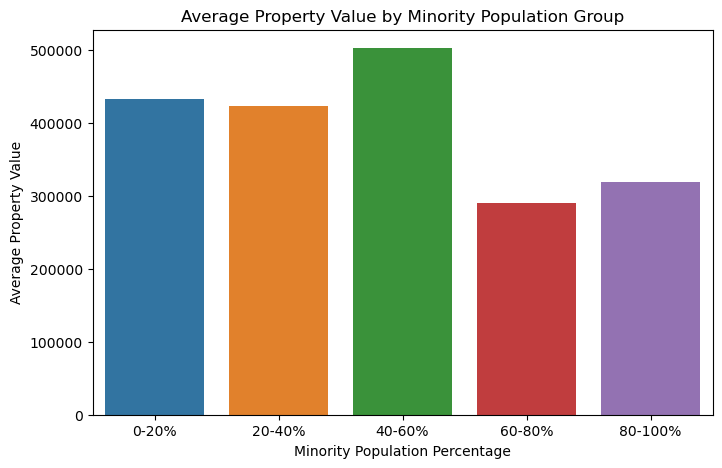

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# convert columns to numeric
df["property_value"] = pd.to_numeric(df["property_value"], errors="coerce")
df["tract_minority_population_percent"] = pd.to_numeric(
    df["tract_minority_population_percent"], errors="coerce"
)

# remove missing values
df_clean = df.dropna(subset=["property_value","tract_minority_population_percent"])

df_clean["minority_group"] = pd.cut(
    df_clean["tract_minority_population_percent"],
    bins=[0,20,40,60,80,100],
    labels=["0-20%","20-40%","40-60%","60-80%","80-100%"]
)

grouped = df_clean.groupby("minority_group")["property_value"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x="minority_group",
    y="property_value",
    data=grouped
)

plt.title("Average Property Value by Minority Population Group")
plt.xlabel("Minority Population Percentage")
plt.ylabel("Average Property Value")

plt.show()

### Income vs Loan Amount

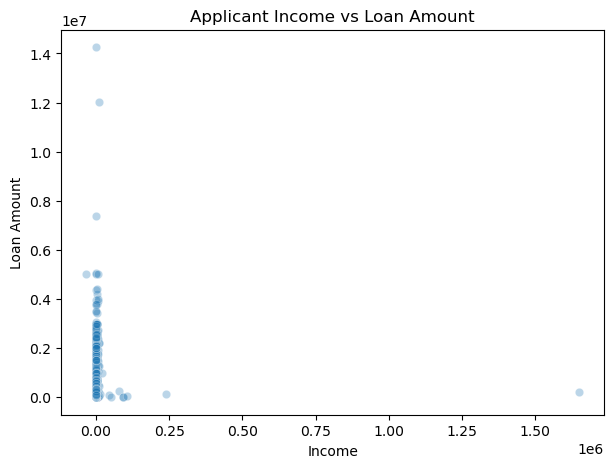

In [60]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="income",
    y="loan_amount",
    data=df,
    alpha=0.3
)

plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")

plt.show()

C:\Users\Tanvi\AppData\Local\Temp\ipykernel_23828\2581005090.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["income_group"] = pd.cut(


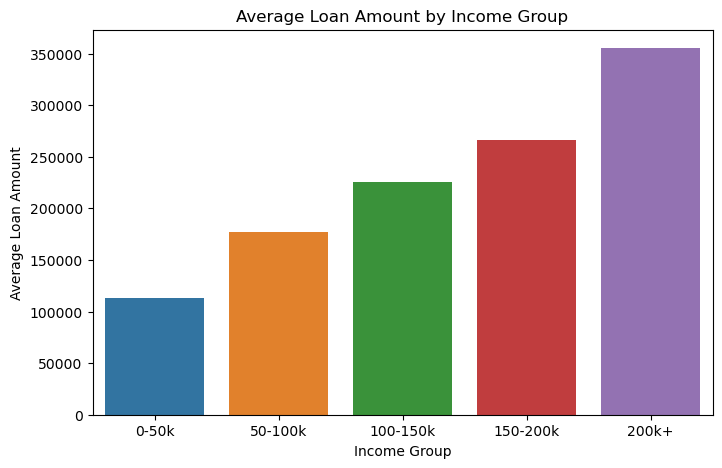

In [62]:

df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

df_clean = df.dropna(subset=["income","loan_amount"])

# create income groups
df_clean["income_group"] = pd.cut(
    df_clean["income"],
    bins=[0,50,100,150,200,500],
    labels=["0-50k","50-100k","100-150k","150-200k","200k+"]
)

# calculate average loan amount
income_loan = df_clean.groupby("income_group")["loan_amount"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x="income_group",
    y="loan_amount",
    data=income_loan
)

plt.title("Average Loan Amount by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Loan Amount")

plt.show()

## Neighborhood Income vs Property Value

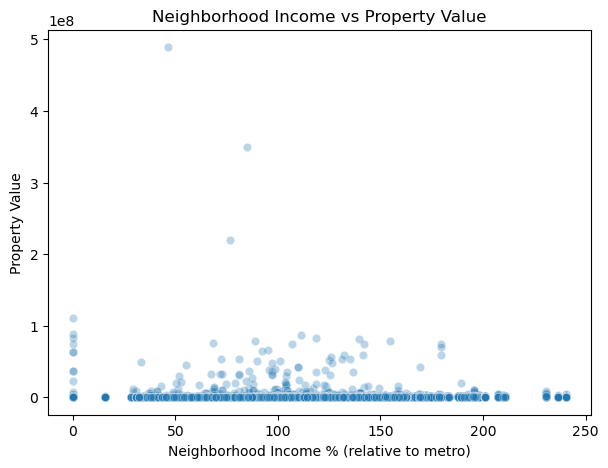

In [69]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="tract_to_msa_income_percentage",
    y="property_value",
    data=df,
    alpha=0.3
)

plt.title("Neighborhood Income vs Property Value")
plt.xlabel("Neighborhood Income % (relative to metro)")
plt.ylabel("Property Value")

plt.show()